In [54]:
from pathlib import Path
from itertools import product

import holidays
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

In [26]:
DATA_PATH = Path("../data/processed/sardinia_hourly.parquet")
df = pd.read_parquet(DATA_PATH)
df = df.rename(columns={"Total Load [MW]": "load"})
df = df.rename(columns={"Forecast Total Load [MW]": "terna-forecast"})

display(df.head())

,load,terna-forecast
Date,,
2023-01-01 00:00:00+01:00,806.13675,833.01000
2023-01-01 01:00:00+01:00,783.55525,779.20525
2023-01-01 02:00:00+01:00,753.62675,749.15025
2023-01-01 03:00:00+01:00,736.34950,739.18250
2023-01-01 04:00:00+01:00,723.29950,749.01150


In [27]:
df["lag_24h"] = df["load"].shift(24)
df["lag_48h"] = df["load"].shift(48)
df["lag_168h"] = df["load"].shift(168)

display(
    df[
        ["load", "lag_24h", "lag_48h", "lag_168h"]
    ].head(170)
)

,load,lag_24h,lag_48h,lag_168h
Date,,,,
2023-01-01 00:00:00+01:00,806.13675,NaN,NaN,NaN
2023-01-01 01:00:00+01:00,783.55525,NaN,NaN,NaN
2023-01-01 02:00:00+01:00,753.62675,NaN,NaN,NaN
2023-01-01 03:00:00+01:00,736.34950,NaN,NaN,NaN
2023-01-01 04:00:00+01:00,723.29950,NaN,NaN,NaN
...,...,...,...,...
2023-01-07 21:00:00+01:00,1009.19525,1012.38225,1034.62100,NaN
2023-01-07 22:00:00+01:00,938.51400,943.02550,977.22425,NaN
2023-01-07 23:00:00+01:00,865.93575,863.03125,890.10025,NaN


In [28]:
italian_holidays = holidays.Italy(
    years=range(df.index.year.min(), df.index.year.max() + 1)
)

local_dates = df.index.tz_convert("Europe/Rome").date

In [29]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)
df["is_holiday"] = [
    int(date in italian_holidays)
    for date in local_dates
]

display(
    df[
        ["load", "lag_24h", "lag_48h", "lag_168h",
         "hour", "day_of_week", "month", "is_weekend", "is_holiday"]
    ].head()
)

,load,lag_24h,lag_48h,lag_168h,hour,day_of_week,month,is_weekend,is_holiday
Date,,,,,,,,,
2023-01-01 00:00:00+01:00,806.13675,NaN,NaN,NaN,0,6,1,1,1
2023-01-01 01:00:00+01:00,783.55525,NaN,NaN,NaN,1,6,1,1,1
2023-01-01 02:00:00+01:00,753.62675,NaN,NaN,NaN,2,6,1,1,1
2023-01-01 03:00:00+01:00,736.34950,NaN,NaN,NaN,3,6,1,1,1
2023-01-01 04:00:00+01:00,723.29950,NaN,NaN,NaN,4,6,1,1,1


In [30]:
WEATHER_PATH = Path("../data/processed/sardinia_weather_hourly.parquet")
weather = pd.read_parquet(WEATHER_PATH)

weather.head()

,temperature_weighted,humidity_weighted,cloud_cover_weighted,temperature_min,temperature_max
time,,,,,
2024-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2024-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2024-01-01 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2024-01-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN


In [31]:
print("Load timezone:", df.index.tz)
print("Weather timezone:", weather.index.tz)

print("Load range:", df.index.min(), "->", df.index.max())
print("Weather range:", weather.index.min(), "->", weather.index.max())

Load timezone: Europe/Rome
Weather timezone: UTC
Load range: 2023-01-01 00:00:00+01:00 -> 2026-10-05 23:00:00+02:00
Weather range: 2024-01-01 00:00:00+00:00 -> 2026-10-05 23:00:00+00:00


In [32]:
df_weather = df.copy()

# Convert load timestamps to UTC
df_weather.index = df_weather.index.tz_convert("UTC")

# Join weather forecasts on the same physical timestamps
df_weather = df_weather.join(weather, how="left")

df_weather.tail()

,load,terna-forecast,lag_24h,lag_48h,lag_168h,hour,day_of_week,month,is_weekend,is_holiday,temperature_weighted,humidity_weighted,cloud_cover_weighted,temperature_min,temperature_max
Date,,,,,,,,,,,,,,,
2026-10-05 17:00:00+00:00,1040.31050,1047.87950,950.88050,961.34675,1035.88400,19,0,10,0,0,24.535286,66.480992,94.982923,20.7,26.7
2026-10-05 18:00:00+00:00,1023.90500,1035.48450,955.09125,944.11200,1028.13000,20,0,10,0,0,23.778437,69.203434,91.039723,19.1,25.4
2026-10-05 19:00:00+00:00,943.76200,952.27725,899.96900,866.38775,950.25450,21,0,10,0,0,23.056816,73.673647,100.000000,18.4,24.7
2026-10-05 20:00:00+00:00,876.53425,883.39825,825.99125,805.69525,876.46550,22,0,10,0,0,22.613356,77.427804,90.632193,18.2,24.1
2026-10-05 21:00:00+00:00,807.51325,812.17200,766.50825,756.42250,810.22375,23,0,10,0,0,22.111887,81.104100,98.283052,18.1,23.6


In [33]:
weather_features = [
    "temperature_weighted",
    "humidity_weighted",
    "cloud_cover_weighted",
    "temperature_min",
    "temperature_max",
]

print(df_weather[weather_features].isna().sum())

temperature_weighted    9205
humidity_weighted       9205
cloud_cover_weighted    9205
temperature_min         9205
temperature_max         9205
dtype: int64


In [34]:
features_weather = [
    "lag_24h",
    "lag_48h",
    "lag_168h",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_holiday",
    "temperature_weighted",
    "humidity_weighted",
    "cloud_cover_weighted",
    "temperature_min",
    "temperature_max",
]

model_weather_df = df_weather[
    ["load"] + features_weather
].dropna()

print("Usable rows:", len(model_weather_df))
print("First timestamp:", model_weather_df.index.min())
print("Last timestamp:", model_weather_df.index.max())

Usable rows: 23626
First timestamp: 2024-01-19 12:00:00+00:00
Last timestamp: 2026-10-05 21:00:00+00:00


In [36]:
X_weather = model_weather_df[features_weather]
y_weather = model_weather_df["load"]

X_train = X_weather.loc[:"2025-12-31 22:59:59+00:00"]
y_train = y_weather.loc[X_train.index]

X_test = X_weather.loc["2025-12-31 23:00:00+00:00":]
y_test = y_weather.loc[X_test.index]

print("Train:", X_train.index.min(), "->", X_train.index.max())
print("Test:", X_test.index.min(), "->", X_test.index.max())

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))

Train: 2024-01-19 12:00:00+00:00 -> 2025-12-31 22:00:00+00:00
Test: 2025-12-31 23:00:00+00:00 -> 2026-10-05 21:00:00+00:00
Train rows: 17099
Test rows: 6527


In [37]:
model = HistGradientBoostingRegressor(
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print(f"Predictions: {len(pred):,}")

Predictions: 6,527


In [38]:
rmse_model = root_mean_squared_error(y_test, pred)
mae_model = mean_absolute_error(y_test, pred)
mape_model = mean_absolute_percentage_error(
    y_test,
    pred
) * 100

print(f"MAE model: {mae_model:.2f} MW")
print(f"RMSE model: {rmse_model:.2f} MW")
print(f"MAPE model: {mape_model:.2f}%")

MAE model: 31.92 MW
RMSE model: 46.35 MW
MAPE model: 2.97%


In [39]:
results = pd.DataFrame(
    {
        "actual": y_test,
        "prediction": pred
    },
    index=y_test.index
)

results["error"] = results["actual"] - results["prediction"]
results["absolute_error"] = results["error"].abs()

results["absolute_percentage_error"] = (
    results["absolute_error"] / results["actual"] * 100
)

# Local time for calendar-based error analysis
local_index = results.index.tz_convert("Europe/Rome")

display(results.head())

,actual,prediction,error,absolute_error,absolute_percentage_error
Date,,,,,
2025-12-31 23:00:00+00:00,809.42325,767.390949,42.032301,42.032301,5.192870
2026-01-01 00:00:00+00:00,774.35375,739.051933,35.301817,35.301817,4.558875
2026-01-01 01:00:00+00:00,740.69925,713.382003,27.317247,27.317247,3.688035
2026-01-01 02:00:00+00:00,716.15600,688.219947,27.936053,27.936053,3.900833
2026-01-01 03:00:00+00:00,706.16175,690.208615,15.953135,15.953135,2.259133


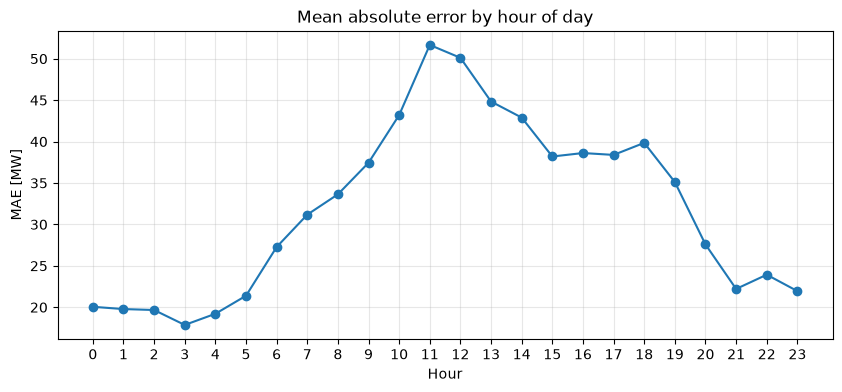

In [40]:
error_by_hour = (
    results.groupby(results.index.hour)["absolute_error"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 4))

error_by_hour.plot(ax=ax, marker="o")

ax.set_title("Mean absolute error by hour of day")
ax.set_xlabel("Hour")
ax.set_ylabel("MAE [MW]")
ax.set_xticks(range(24))
ax.grid(alpha=0.3)

plt.show()

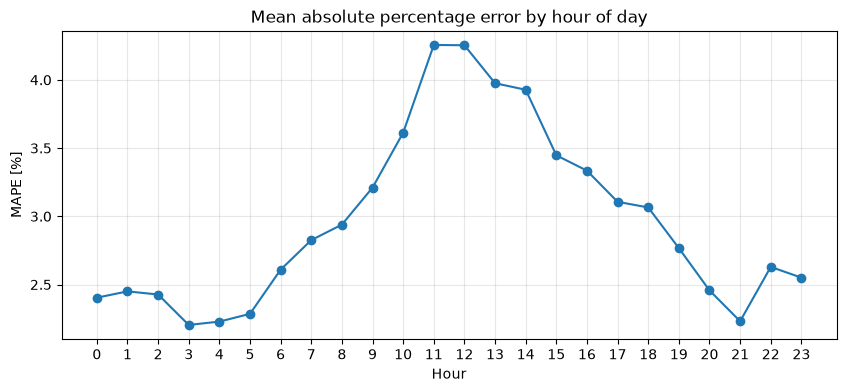

In [41]:
results["absolute_percentage_error"] = (
    results["absolute_error"] / results["actual"] * 100
)

mape_by_hour = (
    results.groupby(results.index.hour)["absolute_percentage_error"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 4))

mape_by_hour.plot(ax=ax, marker="o")

ax.set_title("Mean absolute percentage error by hour of day")
ax.set_xlabel("Hour")
ax.set_ylabel("MAPE [%]")
ax.set_xticks(range(24))
ax.grid(alpha=0.3)

plt.show()

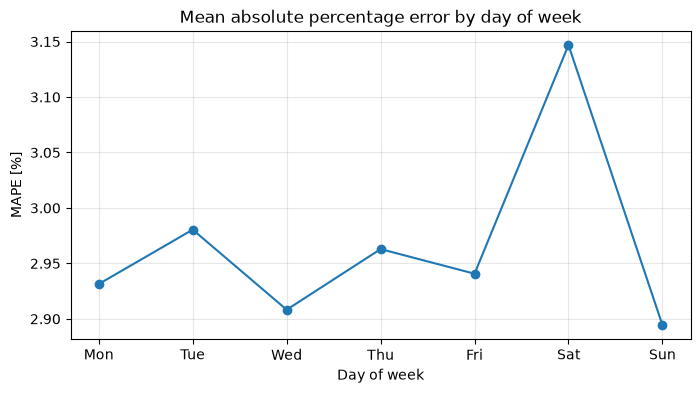

In [42]:
mape_by_weekday = (
    results.groupby(results.index.dayofweek)["absolute_percentage_error"]
    .mean()
)

mape_by_weekday.index = [
    "Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"
]

fig, ax = plt.subplots(figsize=(8, 4))

mape_by_weekday.plot(ax=ax, marker="o")

ax.set_title("Mean absolute percentage error by day of week")
ax.set_xlabel("Day of week")
ax.set_ylabel("MAPE [%]")
ax.grid(alpha=0.3)

plt.show()

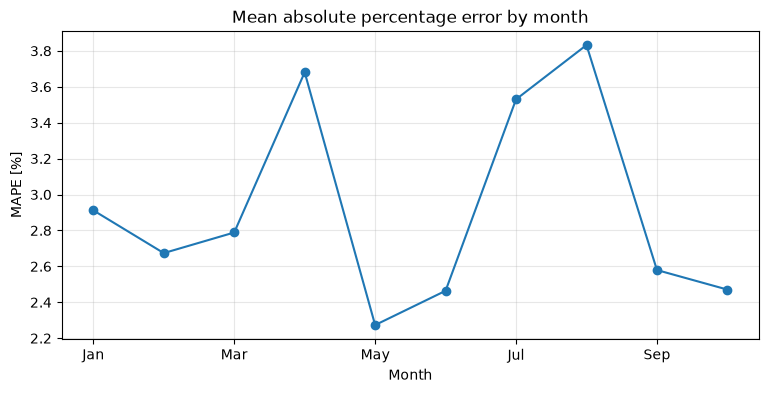

In [43]:
mape_by_month = (
    results["absolute_percentage_error"]
    .groupby(local_index.month)
    .mean()
)

mape_by_month.index = [
    "Jan", "Feb", "Mar", "Apr", "May",
    "Jun", "Jul", "Aug", "Sep", "Oct"
]

fig, ax = plt.subplots(figsize=(9, 4))

mape_by_month.plot(ax=ax, marker="o")

ax.set_title("Mean absolute percentage error by month")
ax.set_xlabel("Month")
ax.set_ylabel("MAPE [%]")
ax.grid(alpha=0.3)

plt.show()

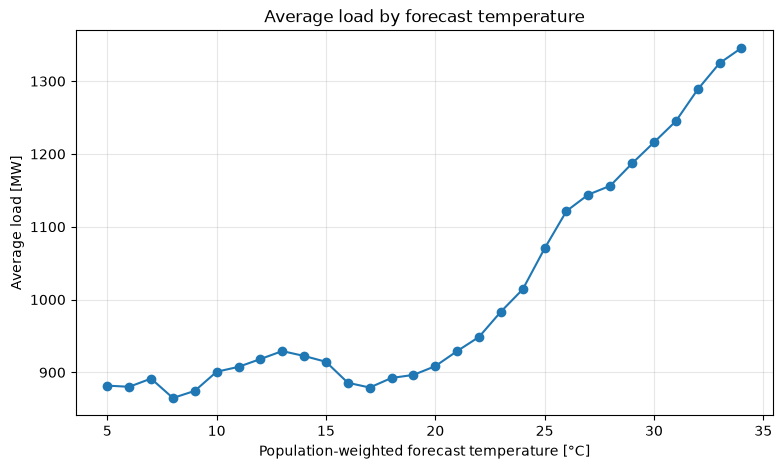

In [44]:
temp_load = df_weather.loc[X_train.index, [
    "load",
    "temperature_weighted"
]].dropna()

temp_load["temperature_bin"] = (
    temp_load["temperature_weighted"]
    .round()
    .astype(int)
)

load_by_temperature = (
    temp_load.groupby("temperature_bin")["load"]
    .agg(["mean", "count"])
)

# Ignore temperature bins with very few observations
load_by_temperature = load_by_temperature[
    load_by_temperature["count"] >= 24
]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    load_by_temperature.index,
    load_by_temperature["mean"],
    marker="o"
)

ax.set_title("Average load by forecast temperature")
ax.set_xlabel("Population-weighted forecast temperature [°C]")
ax.set_ylabel("Average load [MW]")
ax.grid(alpha=0.3)

plt.show()

In [45]:
df_weather["cooling_degree"] = (
    df_weather["temperature_weighted"] - 22
).clip(lower=0)

In [46]:
features_weather = [
    "lag_24h",
    "lag_48h",
    "lag_168h",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_holiday",
    "temperature_weighted",
    "humidity_weighted",
    "cloud_cover_weighted",
    "temperature_min",
    "temperature_max",
    "cooling_degree"
]

model_weather_df = df_weather[
    ["load"] + features_weather
].dropna()

print("Usable rows:", len(model_weather_df))
print("First timestamp:", model_weather_df.index.min())
print("Last timestamp:", model_weather_df.index.max())

Usable rows: 23626
First timestamp: 2024-01-19 12:00:00+00:00
Last timestamp: 2026-10-05 21:00:00+00:00


In [48]:
X_weather = model_weather_df[features_weather]
y_weather = model_weather_df["load"]

X_train = X_weather.loc[:"2025-12-31 22:59:59+00:00"]
y_train = y_weather.loc[X_train.index]

X_test = X_weather.loc["2025-12-31 23:00:00+00:00":]
y_test = y_weather.loc[X_test.index]

print("Train:", X_train.index.min(), "->", X_train.index.max())
print("Test:", X_test.index.min(), "->", X_test.index.max())

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))

Train: 2024-01-19 12:00:00+00:00 -> 2025-12-31 22:00:00+00:00
Test: 2025-12-31 23:00:00+00:00 -> 2026-10-05 21:00:00+00:00
Train rows: 17099
Test rows: 6527


In [49]:
model = HistGradientBoostingRegressor(
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print(f"Predictions: {len(pred):,}")

Predictions: 6,527


In [50]:
rmse_model = root_mean_squared_error(y_test, pred)
mae_model = mean_absolute_error(y_test, pred)
mape_model = mean_absolute_percentage_error(
    y_test,
    pred
) * 100

print(f"MAE model: {mae_model:.2f} MW")
print(f"RMSE model: {rmse_model:.2f} MW")
print(f"MAPE model: {mape_model:.2f}%")

MAE model: 31.92 MW
RMSE model: 46.35 MW
MAPE model: 2.97%


## Feature ablation: weather and weekend

Compare the full model with reduced feature sets using identical complete-case rows, the existing 2026 test period, and `HistGradientBoostingRegressor(random_state=42)`. All load lags and other calendar features stay fixed. Keep `cooling_degree` (derived from weighted temperature) in every variant to isolate the requested removals.

The weighted-only variant removes geographic temperature min/max as well as humidity/cloud cover. Test weekend removal separately against the three-temperature variant. Positive MAE differences mean worse performance. These are exploratory comparisons on the existing test period; confirm any final feature choice on a separate chronological validation period.

Run the data preparation cells through the first `model_weather_df` creation, then this section. It does not depend on the earlier split cells or overwrite their variables.

In [51]:
# Work on a copy; do not change df_weather or the earlier feature lists.
ablation_source = df_weather.copy()
ablation_source["cooling_degree"] = (
    ablation_source["temperature_weighted"] - 22
).clip(lower=0)

ablation_full_features = [
    "lag_24h", "lag_48h", "lag_168h",
    "hour", "day_of_week", "month", "is_weekend", "is_holiday",
    "temperature_weighted", "humidity_weighted", "cloud_cover_weighted",
    "temperature_min", "temperature_max", "cooling_degree",
]
ablation_three_temperature_features = [
    ablation_feature for ablation_feature in ablation_full_features
    if ablation_feature not in {"humidity_weighted", "cloud_cover_weighted"}
]
ablation_feature_sets = {
    "full_weather": ablation_full_features,
    "three_temperatures": ablation_three_temperature_features,
    "weighted_temperature_only": [
        ablation_feature for ablation_feature in ablation_three_temperature_features
        if ablation_feature not in {"temperature_min", "temperature_max"}
    ],
    "three_temperatures_no_weekend": [
        ablation_feature for ablation_feature in ablation_three_temperature_features
        if ablation_feature != "is_weekend"
    ],
}

# Drop missing rows once across the full set so every comparison uses the same data.
ablation_data = ablation_source[["load"] + ablation_full_features].dropna().sort_index()
ablation_cutoff = pd.Timestamp("2026-01-01", tz="Europe/Rome")
ablation_train = ablation_data.loc[ablation_data.index < ablation_cutoff]
ablation_test = ablation_data.loc[ablation_data.index >= ablation_cutoff]
assert not ablation_train.empty and not ablation_test.empty
assert ablation_train.index.max() < ablation_test.index.min()
print(f"Same rows for all variants: {len(ablation_train):,} train / {len(ablation_test):,} test")

Same rows for all variants: 17,099 train / 6,527 test


In [52]:
ablation_models = {}
ablation_predictions = pd.DataFrame({"actual": ablation_test["load"]})
ablation_scores = []

for ablation_name, ablation_columns in ablation_feature_sets.items():
    ablation_estimator = HistGradientBoostingRegressor(random_state=42)
    ablation_estimator.fit(ablation_train[ablation_columns], ablation_train["load"])
    ablation_forecast = ablation_estimator.predict(ablation_test[ablation_columns])
    ablation_models[ablation_name] = ablation_estimator
    ablation_predictions[ablation_name] = ablation_forecast
    ablation_scores.append({
        "variant": ablation_name,
        "n_features": len(ablation_columns),
        "MAE_MW": mean_absolute_error(ablation_test["load"], ablation_forecast),
        "RMSE_MW": root_mean_squared_error(ablation_test["load"], ablation_forecast),
        "MAPE_pct": 100 * mean_absolute_percentage_error(ablation_test["load"], ablation_forecast),
    })

ablation_results = pd.DataFrame(ablation_scores).set_index("variant")
ablation_results["delta_MAE_vs_full_MW"] = (
    ablation_results["MAE_MW"] - ablation_results.loc["full_weather", "MAE_MW"]
)
display(ablation_results.round(3))

,n_features,MAE_MW,RMSE_MW,MAPE_pct,delta_MAE_vs_full_MW
variant,,,,,
full_weather,14,31.918,46.353,2.967,0.000
three_temperatures,12,32.306,46.878,2.997,0.388
weighted_temperature_only,10,32.441,47.295,3.003,0.523
three_temperatures_no_weekend,11,32.306,46.878,2.997,0.388


In [53]:
# Paired comparisons isolate each reduction; negative values mean an improvement.
ablation_comparisons = pd.DataFrame([
    {
        "change": "Remove humidity and cloud cover",
        "delta_MAE_MW": ablation_results.loc["three_temperatures", "MAE_MW"]
            - ablation_results.loc["full_weather", "MAE_MW"],
    },
    {
        "change": "Also remove temperature min/max",
        "delta_MAE_MW": ablation_results.loc["weighted_temperature_only", "MAE_MW"]
            - ablation_results.loc["three_temperatures", "MAE_MW"],
    },
    {
        "change": "Remove weekend from three-temperature model",
        "delta_MAE_MW": ablation_results.loc["three_temperatures_no_weekend", "MAE_MW"]
            - ablation_results.loc["three_temperatures", "MAE_MW"],
    },
]).set_index("change")
display(ablation_comparisons.round(3))

# Trained variants remain available in ablation_models and ablation_predictions.

,delta_MAE_MW
change,
Remove humidity and cloud cover,0.388
Also remove temperature min/max,0.135
Remove weekend from three-temperature model,0.000
